In [1]:
# ============================================================
# AI WEEK 6 FINAL PROJECT
# AI-BASED STUDENT PERFORMANCE PREDICTION
# AND PERSONALIZED RECOMMENDATION SYSTEM
# ============================================================

print("=" * 70)
print("AI-BASED STUDENT PERFORMANCE PREDICTION SYSTEM")
print("=" * 70)

print("""
Project Features:
1. Data Generation / Loading
2. Data Preprocessing
3. Exploratory Data Analysis
4. Machine Learning
5. Random Forest
6. XGBoost
7. Artificial Neural Network
8. Model Comparison
9. Prediction System
10. Intelligent Recommendation System
11. Data Visualization
12. User Interaction
""")

AI-BASED STUDENT PERFORMANCE PREDICTION SYSTEM

Project Features:
1. Data Generation / Loading
2. Data Preprocessing
3. Exploratory Data Analysis
4. Machine Learning
5. Random Forest
6. XGBoost
7. Artificial Neural Network
8. Model Comparison
9. Prediction System
10. Intelligent Recommendation System
11. Data Visualization
12. User Interaction



In [2]:
# Install required libraries

!pip install -q xgboost seaborn scikit-learn pandas numpy matplotlib

In [3]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# ============================================================
# GENERATE STUDENT DATASET
# ============================================================

np.random.seed(42)

number_of_students = 2000

study_hours = np.random.uniform(
    0.5, 8, number_of_students
)

attendance = np.random.uniform(
    45, 100, number_of_students
)

previous_score = np.random.uniform(
    30, 100, number_of_students
)

assignment_score = np.random.uniform(
    30, 100, number_of_students
)

quiz_score = np.random.uniform(
    30, 100, number_of_students
)

sleep_hours = np.random.uniform(
    4, 9, number_of_students
)

participation = np.random.randint(
    1, 11, number_of_students
)

completed_assignments = np.random.randint(
    1, 11, number_of_students
)


# ------------------------------------------------------------
# Generate final score
# ------------------------------------------------------------

final_score = (
    study_hours * 3.5
    + attendance * 0.18
    + previous_score * 0.20
    + assignment_score * 0.12
    + quiz_score * 0.10
    + sleep_hours * 1.5
    + participation * 0.8
    + completed_assignments * 1.0
    + np.random.normal(0, 5, number_of_students)
)

final_score = np.clip(
    final_score,
    0,
    100
)


# ------------------------------------------------------------
# Convert score into performance class
# ------------------------------------------------------------

def performance_class(score):

    if score >= 80:
        return 3

    elif score >= 65:
        return 2

    elif score >= 50:
        return 1

    else:
        return 0


performance = [
    performance_class(score)
    for score in final_score
]


# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

df = pd.DataFrame({

    "Study_Hours": study_hours,

    "Attendance": attendance,

    "Previous_Score": previous_score,

    "Assignment_Score": assignment_score,

    "Quiz_Score": quiz_score,

    "Sleep_Hours": sleep_hours,

    "Participation": participation,

    "Completed_Assignments": completed_assignments,

    "Final_Score": final_score,

    "Performance": performance
})


print("Dataset generated successfully!")
print("Number of students:", len(df))

Dataset generated successfully!
Number of students: 2000


In [5]:
# ============================================================
# SAVE DATASET
# ============================================================

df.to_csv(
    "student_performance.csv",
    index=False
)

print("Dataset saved as student_performance.csv")

Dataset saved as student_performance.csv


In [6]:
# ============================================================
# DISPLAY DATASET
# ============================================================

print("First 10 records:")
display(df.head(10))

First 10 records:


,Study_Hours,Attendance,Previous_Score,Assignment_Score,Quiz_Score,Sleep_Hours,Participation,Completed_Assignments,Final_Score,Performance
0,3.309051,59.393813,70.039711,75.377987,80.418755,5.868204,6,9,71.804339,2
1,7.630357,58.583834,86.380263,42.067045,78.109810,5.664560,4,7,91.413079,3
2,5.989955,94.844002,83.211265,91.067619,36.702794,4.880770,7,5,87.287724,3
3,4.989939,58.725041,40.772993,72.918137,94.580068,7.036333,3,3,70.540409,2
4,1.670140,59.957235,40.447463,41.004272,69.793054,6.383121,5,8,52.188426,1
5,1.669959,86.766904,48.772206,97.363664,55.460786,8.328505,1,10,66.789747,2
6,0.935627,69.735691,55.275231,66.285582,82.957701,4.160548,10,4,57.247541,1
7,6.996321,87.719081,58.591891,35.102892,48.015582,7.219340,3,9,83.470158,3
8,5.008363,48.595139,77.578805,73.878303,78.545689,7.814744,8,5,82.023666,3
9,5.810544,71.816416,33.967630,47.723923,32.779785,7.797433,9,6,81.678848,3


In [7]:
# ============================================================
# DATASET INFORMATION
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(2000, 10)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours            2000 non-null   float64
 1   Attendance             2000 non-null   float64
 2   Previous_Score         2000 non-null   float64
 3   Assignment_Score       2000 non-null   float64
 4   Quiz_Score             2000 non-null   float64
 5   Sleep_Hours            2000 non-null   float64
 6   Participation          2000 non-null   int64  
 7   Completed_Assignments  2000 non-null   int64  
 8   Final_Score            2000 non-null   float64
 9   Performance            2000 non-null   int64  
dtypes: float64(7), int64(3)
memory usage: 156.4 KB

Statistical Summary:


,Study_Hours,Attendance,Previous_Score,Assignment_Score,Quiz_Score,Sleep_Hours,Participation,Completed_Assignments,Final_Score,Performance
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.239777,72.301471,64.739943,64.148781,64.415209,6.527358,5.439500,5.456000,74.655988,2.098500
std,2.191581,15.871894,20.155874,20.112003,19.751921,1.456400,2.893359,2.882919,11.812729,0.770775
min,0.524137,45.000640,30.002150,30.016870,30.003698,4.000789,1.000000,1.000000,35.844752,0.000000
25%,2.285349,58.793272,47.285459,46.753110,47.728363,5.264348,3.000000,3.000000,66.129550,2.000000
50%,4.305135,72.098188,64.405752,63.893917,64.069268,6.516094,5.000000,5.000000,74.982675,2.000000
75%,6.130091,86.177978,81.789624,81.599353,81.077860,7.813637,8.000000,8.000000,83.291651,3.000000
max,7.997883,99.975674,99.954521,99.962248,99.965363,8.998366,10.000000,10.000000,100.000000,3.000000


In [8]:
# ============================================================
# CHECK MISSING VALUES
# ============================================================

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Study_Hours              0
Attendance               0
Previous_Score           0
Assignment_Score         0
Quiz_Score               0
Sleep_Hours              0
Participation            0
Completed_Assignments    0
Final_Score              0
Performance              0
dtype: int64


In [9]:
# ============================================================
# DATA PREPROCESSING
# ============================================================

# Remove duplicate records
df = df.drop_duplicates()

# Handle missing numerical values
numeric_columns = df.select_dtypes(
    include=np.number
).columns

for column in numeric_columns:

    df[column] = df[column].fillna(
        df[column].median()
    )


print("Preprocessing completed!")

print("Dataset shape after preprocessing:")
print(df.shape)

Preprocessing completed!
Dataset shape after preprocessing:
(2000, 10)


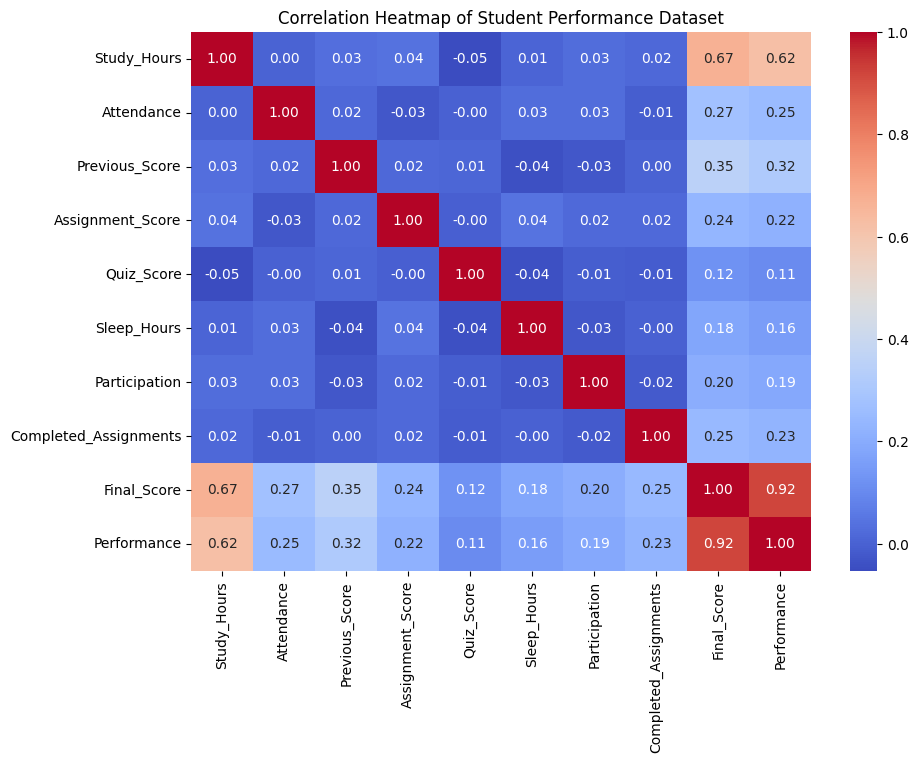

In [10]:
# ============================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================

plt.figure(figsize=(10, 7))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap of Student Performance Dataset"
)

plt.show()

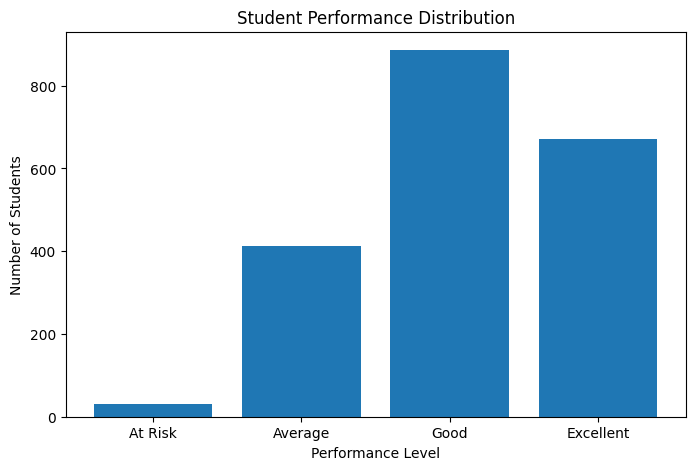

In [11]:
# ============================================================
# PERFORMANCE DISTRIBUTION
# ============================================================

performance_names = {
    0: "At Risk",
    1: "Average",
    2: "Good",
    3: "Excellent"
}

performance_counts = df[
    "Performance"
].value_counts().sort_index()

labels = [
    performance_names[i]
    for i in performance_counts.index
]

plt.figure(figsize=(8, 5))

plt.bar(
    labels,
    performance_counts.values
)

plt.title(
    "Student Performance Distribution"
)

plt.xlabel(
    "Performance Level"
)

plt.ylabel(
    "Number of Students"
)

plt.show()

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

# Define features (X) and target (y)
X = df.drop(['Final_Score', 'Performance'], axis=1)
y = df['Performance']

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("Training samples:", len(X_train))

print("Testing samples:", len(X_test))

Training samples: 1600
Testing samples: 400


In [14]:
# ============================================================
# RANDOM FOREST MODEL
# ============================================================

random_forest = RandomForestClassifier(

    n_estimators=250,

    max_depth=12,

    min_samples_split=4,

    random_state=42
)


random_forest.fit(
    X_train,
    y_train
)


rf_prediction = random_forest.predict(
    X_test
)


rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)


print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

Random Forest Accuracy: 73.0 %


In [15]:
# ============================================================
# RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        rf_prediction,
        target_names=[
            "At Risk",
            "Average",
            "Good",
            "Excellent"
        ]
    )
)

              precision    recall  f1-score   support

     At Risk       0.00      0.00      0.00         6
     Average       0.75      0.55      0.64        83
        Good       0.67      0.84      0.74       177
   Excellent       0.84      0.72      0.78       134

    accuracy                           0.73       400
   macro avg       0.56      0.53      0.54       400
weighted avg       0.73      0.73      0.72       400



In [16]:
# ============================================================
# XGBOOST MODEL
# ============================================================

xgb_model = XGBClassifier(

    n_estimators=250,

    max_depth=5,

    learning_rate=0.05,

    subsample=0.9,

    colsample_bytree=0.9,

    objective="multi:softprob",

    num_class=4,

    eval_metric="mlogloss",

    random_state=42
)


xgb_model.fit(
    X_train,
    y_train
)


xgb_prediction = xgb_model.predict(
    X_test
)


xgb_accuracy = accuracy_score(
    y_test,
    xgb_prediction
)


print(
    "XGBoost Accuracy:",
    round(xgb_accuracy * 100, 2),
    "%"
)

XGBoost Accuracy: 72.25 %


In [18]:
# ============================================================
# ARTIFICIAL NEURAL NETWORK
# ============================================================

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ann_model = MLPClassifier(

    hidden_layer_sizes=(
        64,
        32,
        16
    ),

    activation="relu",

    solver="adam",

    learning_rate_init=0.001,

    max_iter=500,

    early_stopping=True,

    validation_fraction=0.15,

    random_state=42
)


ann_model.fit(
    X_train_scaled,
    y_train
)


ann_prediction = ann_model.predict(
    X_test_scaled
)


ann_accuracy = accuracy_score(
    y_test,
    ann_prediction
)


print(
    "Neural Network Accuracy:",
    round(ann_accuracy * 100, 2),
    "%"
)

Neural Network Accuracy: 73.75 %


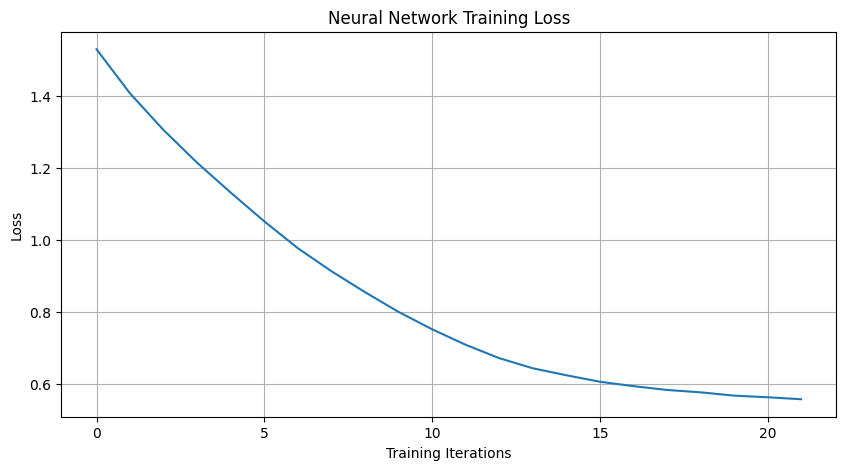

In [19]:
# ============================================================
# NEURAL NETWORK LOSS CURVE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    ann_model.loss_curve_
)

plt.title(
    "Neural Network Training Loss"
)

plt.xlabel(
    "Training Iterations"
)

plt.ylabel(
    "Loss"
)

plt.grid()

plt.show()

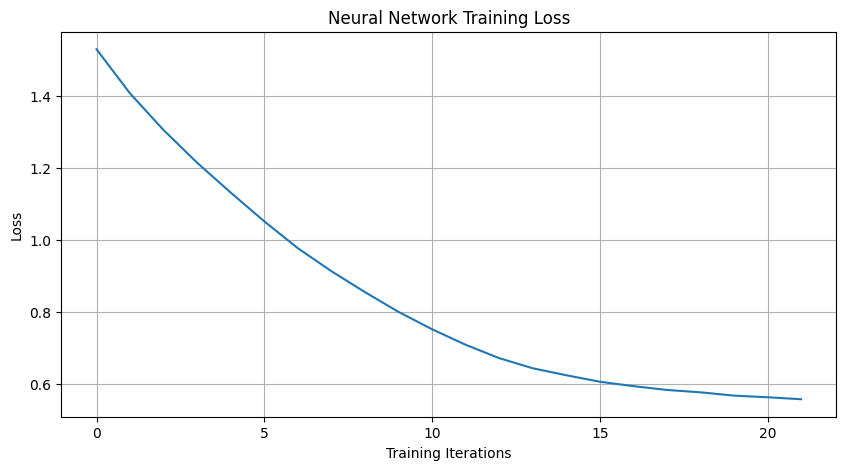

In [20]:
# ============================================================
# NEURAL NETWORK LOSS CURVE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    ann_model.loss_curve_
)

plt.title(
    "Neural Network Training Loss"
)

plt.xlabel(
    "Training Iterations"
)

plt.ylabel(
    "Loss"
)

plt.grid()

plt.show()

In [21]:
# ============================================================
# MODEL COMPARISON
# ============================================================

model_names = [

    "Random Forest",

    "XGBoost",

    "Neural Network"
]


model_accuracies = [

    rf_accuracy * 100,

    xgb_accuracy * 100,

    ann_accuracy * 100
]


comparison = pd.DataFrame({

    "Model": model_names,

    "Accuracy (%)": model_accuracies

})


display(comparison)

,Model,Accuracy (%)
0,Random Forest,73.00
1,XGBoost,72.25
2,Neural Network,73.75


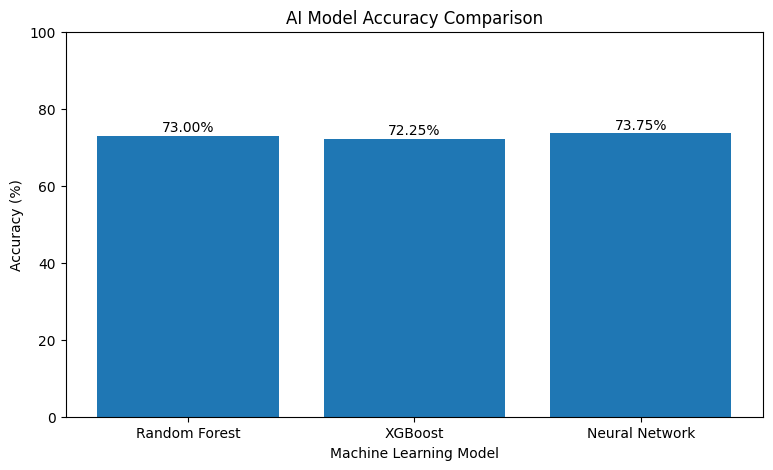

In [22]:
# ============================================================
# MODEL ACCURACY VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 5))

bars = plt.bar(
    model_names,
    model_accuracies
)

plt.title(
    "AI Model Accuracy Comparison"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.ylim(
    0,
    100
)

for bar, value in zip(
    bars,
    model_accuracies
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

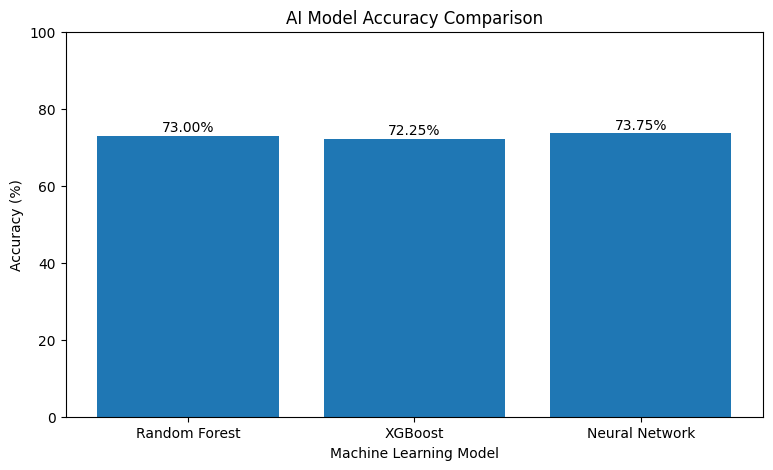

In [23]:
# ============================================================
# MODEL ACCURACY VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 5))

bars = plt.bar(
    model_names,
    model_accuracies
)

plt.title(
    "AI Model Accuracy Comparison"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.ylim(
    0,
    100
)

for bar, value in zip(
    bars,
    model_accuracies
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

In [25]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

features = X.columns

feature_importance = pd.DataFrame({

    "Feature": features,

    "Importance": random_forest.feature_importances_

})


feature_importance = feature_importance.sort_values(

    "Importance",

    ascending=False
)


display(
    feature_importance
)

,Feature,Importance
0,Study_Hours,0.296954
2,Previous_Score,0.140700
1,Attendance,0.119839
3,Assignment_Score,0.108088
5,Sleep_Hours,0.096252
4,Quiz_Score,0.092374
7,Completed_Assignments,0.079194
6,Participation,0.066599


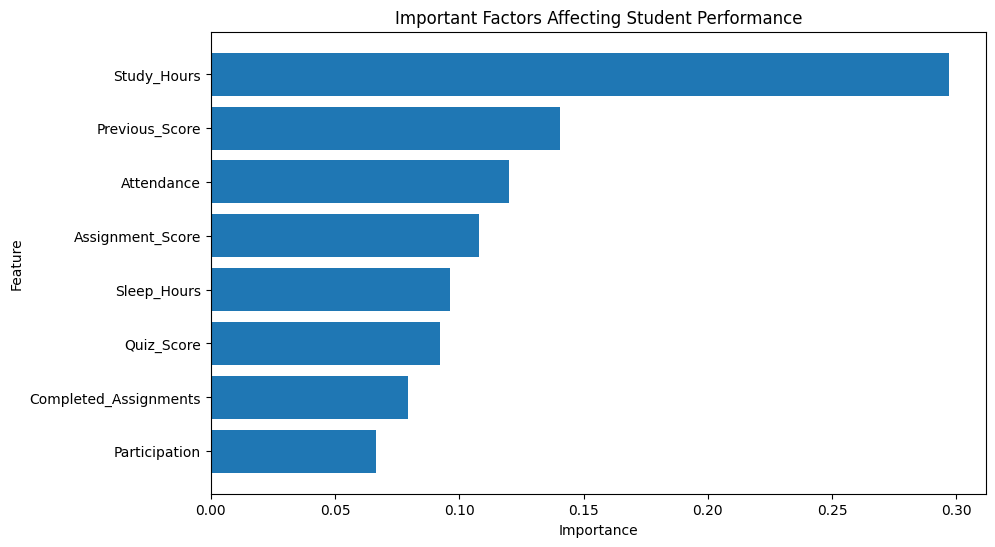

In [26]:
# ============================================================
# FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(

    feature_importance["Feature"],

    feature_importance["Importance"]

)

plt.gca().invert_yaxis()

plt.title(
    "Important Factors Affecting Student Performance"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.show()

In [27]:
# ============================================================
# MODEL EVALUATION METRICS
# ============================================================

rf_precision = precision_score(
    y_test,
    rf_prediction,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    rf_prediction,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    rf_prediction,
    average="weighted"
)


metrics = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Score": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]

})


metrics["Score (%)"] = (
    metrics["Score"] * 100
)


display(
    metrics
)

,Metric,Score,Score (%)
0,Accuracy,0.730000,73.000000
1,Precision,0.732266,73.226616
2,Recall,0.730000,73.000000
3,F1 Score,0.722192,72.219194


In [28]:
# ============================================================
# INTELLIGENT RECOMMENDATION ENGINE
# ============================================================

def generate_recommendations(

    study_hours,

    attendance,

    previous_score,

    assignment_score,

    quiz_score,

    sleep_hours,

    participation,

    completed_assignments

):

    recommendations = []


    # Study hours
    if study_hours < 2:

        recommendations.append(
            "Increase daily study time to at least 2-4 hours."
        )

    elif study_hours < 4:

        recommendations.append(
            "Your study time is moderate. Consider increasing it gradually."
        )

    else:

        recommendations.append(
            "Your study time is good. Maintain your current study routine."
        )


    # Attendance
    if attendance < 70:

        recommendations.append(
            "Your attendance is low. Attend classes regularly."
        )

    elif attendance < 85:

        recommendations.append(
            "Your attendance is acceptable but could be improved."
        )

    else:

        recommendations.append(
            "Excellent attendance. Continue maintaining it."
        )


    # Previous score
    if previous_score < 60:

        recommendations.append(
            "Focus on weak subjects and revise previous topics."
        )


    # Assignment
    if assignment_score < 60:

        recommendations.append(
            "Complete assignments regularly and submit them on time."
        )


    # Quiz
    if quiz_score < 60:

        recommendations.append(
            "Practice more quizzes and review incorrect answers."
        )


    # Sleep
    if sleep_hours < 6:

        recommendations.append(
            "Try to get approximately 6-8 hours of sleep."
        )


    # Participation
    if participation < 5:

        recommendations.append(
            "Increase class participation and ask questions."
        )


    # Assignments
    if completed_assignments < 6:

        recommendations.append(
            "Complete more assignments and practice exercises."
        )


    if len(recommendations) == 0:

        recommendations.append(
            "Your academic indicators look strong. Maintain your current routine."
        )


    return recommendations


print(
    "Recommendation engine created successfully!"
)

Recommendation engine created successfully!


In [29]:
# ============================================================
# COMPLETE AI PREDICTION FUNCTION
# ============================================================

performance_names = {

    0: "At Risk",

    1: "Average",

    2: "Good",

    3: "Excellent"
}


def predict_student(

    study_hours,

    attendance,

    previous_score,

    assignment_score,

    quiz_score,

    sleep_hours,

    participation,

    completed_assignments

):

    input_data = pd.DataFrame({

        "Study_Hours": [
            study_hours
        ],

        "Attendance": [
            attendance
        ],

        "Previous_Score": [
            previous_score
        ],

        "Assignment_Score": [
            assignment_score
        ],

        "Quiz_Score": [
            quiz_score
        ],

        "Sleep_Hours": [
            sleep_hours
        ],

        "Participation": [
            participation
        ],

        "Completed_Assignments": [
            completed_assignments
        ]

    })


    # Random Forest
    rf_result = random_forest.predict(
        input_data
    )[0]

    rf_probability = random_forest.predict_proba(
        input_data
    ).max()


    # XGBoost
    xgb_result = xgb_model.predict(
        input_data
    )[0]

    xgb_probability = xgb_model.predict_proba(
        input_data
    ).max()


    # ANN
    input_scaled = scaler.transform(
        input_data
    )

    ann_result = ann_model.predict(
        input_scaled
    )[0]

    ann_probability = ann_model.predict_proba(
        input_scaled
    ).max()


    # Ensemble
    predictions = [

        rf_result,

        xgb_result,

        ann_result

    ]


    final_prediction = int(
        round(
            np.mean(predictions)
        )
    )


    final_prediction = max(
        0,
        min(
            3,
            final_prediction
        )
    )


    confidence = np.mean([

        rf_probability,

        xgb_probability,

        ann_probability

    ])


    return {

        "Random Forest": performance_names[
            int(rf_result)
        ],

        "XGBoost": performance_names[
            int(xgb_result)
        ],

        "Neural Network": performance_names[
            int(ann_result)
        ],

        "Final Prediction": performance_names[
            final_prediction
        ],

        "Confidence": confidence

    }

In [30]:
# ============================================================
# TEST THE AI SYSTEM
# ============================================================

result = predict_student(

    study_hours=4,

    attendance=85,

    previous_score=75,

    assignment_score=80,

    quiz_score=78,

    sleep_hours=7,

    participation=8,

    completed_assignments=9

)


print("=" * 50)

print("AI PREDICTION RESULT")

print("=" * 50)


for key, value in result.items():

    if key == "Confidence":

        print(
            key,
            ":",
            round(value * 100, 2),
            "%"
        )

    else:

        print(
            key,
            ":",
            value
        )

AI PREDICTION RESULT
Random Forest : Excellent
XGBoost : Excellent
Neural Network : Excellent
Final Prediction : Excellent
Confidence : 73.23 %


In [31]:
# ============================================================
# INTERACTIVE STUDENT PREDICTION SYSTEM
# ============================================================

print("=" * 60)

print("ENTER STUDENT INFORMATION")

print("=" * 60)


study_hours = float(
    input("Study hours per day: ")
)

attendance = float(
    input("Attendance percentage: ")
)

previous_score = float(
    input("Previous exam score: ")
)

assignment_score = float(
    input("Assignment score: ")
)

quiz_score = float(
    input("Quiz score: ")
)

sleep_hours = float(
    input("Sleep hours per day: ")
)

participation = int(
    input("Participation level (1-10): ")
)

completed_assignments = int(
    input("Completed assignments (0-10): ")
)


result = predict_student(

    study_hours,

    attendance,

    previous_score,

    assignment_score,

    quiz_score,

    sleep_hours,

    participation,

    completed_assignments

)


print("\n")
print("=" * 60)

print("AI PREDICTION")

print("=" * 60)


for key, value in result.items():

    if key == "Confidence":

        print(
            f"{key}: {value * 100:.2f}%"
        )

    else:

        print(
            f"{key}: {value}"
        )

ENTER STUDENT INFORMATION
Study hours per day: 4
Attendance percentage: 904
Previous exam score: 90
Assignment score: 10
Quiz score: 10
Sleep hours per day: 12
Participation level (1-10): 7
Completed assignments (0-10): 9


AI PREDICTION
Random Forest: Excellent
XGBoost: Excellent
Neural Network: Excellent
Final Prediction: Excellent
Confidence: 73.51%


In [32]:
# ============================================================
# PERSONALIZED RECOMMENDATIONS
# ============================================================

recommendations = generate_recommendations(

    study_hours,

    attendance,

    previous_score,

    assignment_score,

    quiz_score,

    sleep_hours,

    participation,

    completed_assignments

)


print("=" * 60)

print("PERSONALIZED AI RECOMMENDATIONS")

print("=" * 60)


for i, recommendation in enumerate(
    recommendations,
    1
):

    print(
        f"{i}. {recommendation}"
    )

PERSONALIZED AI RECOMMENDATIONS
1. Your study time is good. Maintain your current study routine.
2. Excellent attendance. Continue maintaining it.
3. Complete assignments regularly and submit them on time.
4. Practice more quizzes and review incorrect answers.


In [33]:
# ============================================================
# FINAL AI DASHBOARD
# ============================================================

print("\n")
print("=" * 70)
print("          AI STUDENT PERFORMANCE DASHBOARD")
print("=" * 70)

print(
    f"\n📚 Study Hours: {study_hours}"
)

print(
    f"🏫 Attendance: {attendance}%"
)

print(
    f"📊 Previous Score: {previous_score}%"
)

print(
    f"📝 Assignment Score: {assignment_score}%"
)

print(
    f"✏️ Quiz Score: {quiz_score}%"
)

print(
    f"😴 Sleep Hours: {sleep_hours}"
)

print(
    f"🙋 Participation: {participation}/10"
)

print(
    f"📚 Completed Assignments: {completed_assignments}/10"
)


print("\n" + "-" * 70)

print("🤖 MODEL PREDICTIONS")

print("-" * 70)


print(
    "Random Forest:",
    result["Random Forest"]
)

print(
    "XGBoost:",
    result["XGBoost"]
)

print(
    "Neural Network:",
    result["Neural Network"]
)


print("\n" + "-" * 70)

print(
    "🎯 FINAL AI PREDICTION:",
    result["Final Prediction"]
)

print(
    "🎯 AI CONFIDENCE:",
    f"{result['Confidence'] * 100:.2f}%"
)


print("\n" + "-" * 70)

print("💡 RECOMMENDATIONS")

print("-" * 70)


for recommendation in recommendations:

    print(
        "•",
        recommendation
    )


print("\n" + "=" * 70)
print("              PROJECT COMPLETED")
print("=" * 70)



          AI STUDENT PERFORMANCE DASHBOARD

📚 Study Hours: 4.0
🏫 Attendance: 904.0%
📊 Previous Score: 90.0%
📝 Assignment Score: 10.0%
✏️ Quiz Score: 10.0%
😴 Sleep Hours: 12.0
🙋 Participation: 7/10
📚 Completed Assignments: 9/10

----------------------------------------------------------------------
🤖 MODEL PREDICTIONS
----------------------------------------------------------------------
Random Forest: Excellent
XGBoost: Excellent
Neural Network: Excellent

----------------------------------------------------------------------
🎯 FINAL AI PREDICTION: Excellent
🎯 AI CONFIDENCE: 73.51%

----------------------------------------------------------------------
💡 RECOMMENDATIONS
----------------------------------------------------------------------
• Your study time is good. Maintain your current study routine.
• Excellent attendance. Continue maintaining it.
• Complete assignments regularly and submit them on time.
• Practice more quizzes and review incorrect answers.

              PROJECT 

In [34]:
# ============================================================
# DOWNLOAD DATASET
# ============================================================

from google.colab import files

files.download(
    "student_performance.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
# ============================================================
# 🎓 GRADIO AI STUDENT PERFORMANCE INTERFACE
# Burgundy + White Theme
# ============================================================

!pip install -q gradio

import gradio as gr
import numpy as np
import pandas as pd


# ============================================================
# PERFORMANCE LABELS
# ============================================================

performance_names = {
    0: "🔴 At Risk",
    1: "🟡 Average",
    2: "🔵 Good",
    3: "🟢 Excellent"
}


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def gradio_prediction(
    study_hours,
    attendance,
    previous_score,
    assignment_score,
    quiz_score,
    sleep_hours,
    participation,
    completed_assignments
):

    # Create input DataFrame
    input_data = pd.DataFrame({

        "Study_Hours": [study_hours],

        "Attendance": [attendance],

        "Previous_Score": [previous_score],

        "Assignment_Score": [assignment_score],

        "Quiz_Score": [quiz_score],

        "Sleep_Hours": [sleep_hours],

        "Participation": [participation],

        "Completed_Assignments": [completed_assignments]
    })


    # --------------------------------------------------------
    # RANDOM FOREST
    # --------------------------------------------------------

    rf_result = random_forest.predict(
        input_data
    )[0]

    rf_probability = random_forest.predict_proba(
        input_data
    ).max()


    # --------------------------------------------------------
    # XGBOOST
    # --------------------------------------------------------

    xgb_result = xgb_model.predict(
        input_data
    )[0]

    xgb_probability = xgb_model.predict_proba(
        input_data
    ).max()


    # --------------------------------------------------------
    # NEURAL NETWORK
    # --------------------------------------------------------

    input_scaled = scaler.transform(
        input_data
    )

    ann_result = ann_model.predict(
        input_scaled
    )[0]

    ann_probability = ann_model.predict_proba(
        input_scaled
    ).max()


    # --------------------------------------------------------
    # ENSEMBLE PREDICTION
    # --------------------------------------------------------

    predictions = [
        int(rf_result),
        int(xgb_result),
        int(ann_result)
    ]

    final_prediction = int(
        round(
            np.mean(predictions)
        )
    )

    final_prediction = max(
        0,
        min(
            3,
            final_prediction
        )
    )


    # --------------------------------------------------------
    # CONFIDENCE
    # --------------------------------------------------------

    confidence = np.mean([
        rf_probability,
        xgb_probability,
        ann_probability
    ])


    # --------------------------------------------------------
    # ESTIMATED SCORE
    # --------------------------------------------------------

    score_ranges = {

        0: (30, 49),

        1: (50, 64),

        2: (65, 79),

        3: (80, 100)
    }

    low, high = score_ranges[
        final_prediction
    ]

    estimated_score = (
        low + high
    ) / 2


    # --------------------------------------------------------
    # RISK LEVEL
    # --------------------------------------------------------

    if final_prediction == 0:

        risk = "🔴 HIGH RISK"

    elif final_prediction == 1:

        risk = "🟡 MEDIUM RISK"

    elif final_prediction == 2:

        risk = "🔵 LOW RISK"

    else:

        risk = "🟢 VERY LOW RISK"


    # --------------------------------------------------------
    # RECOMMENDATIONS
    # --------------------------------------------------------

    recommendations = generate_recommendations(

        study_hours,

        attendance,

        previous_score,

        assignment_score,

        quiz_score,

        sleep_hours,

        participation,

        completed_assignments
    )


    recommendation_text = "\n\n".join(

        [
            f"• {recommendation}"
            for recommendation in recommendations
        ]
    )


    # --------------------------------------------------------
    # RESULT HTML
    # --------------------------------------------------------

    result_html = f"""

    <div class="result-container">

        <div class="result-title">
            AI Prediction Result
        </div>

        <div class="prediction-card">

            <div class="prediction-label">
                FINAL PERFORMANCE
            </div>

            <div class="prediction-value">
                {performance_names[final_prediction]}
            </div>

        </div>


        <div class="stats-grid">

            <div class="stat-card">

                <div class="stat-label">
                    ESTIMATED SCORE
                </div>

                <div class="stat-value">
                    {estimated_score:.0f}%
                </div>

            </div>


            <div class="stat-card">

                <div class="stat-label">
                    AI CONFIDENCE
                </div>

                <div class="stat-value">
                    {confidence * 100:.1f}%
                </div>

            </div>


            <div class="stat-card">

                <div class="stat-label">
                    RISK LEVEL
                </div>

                <div class="stat-value">
                    {risk}
                </div>

            </div>

        </div>


        <div class="models-title">
            MODEL PREDICTIONS
        </div>


        <div class="model-grid">

            <div class="model-card">

                <b>Random Forest</b>

                <br>

                {performance_names[int(rf_result)]}

                <br>

                <small>
                    Confidence: {rf_probability * 100:.1f}%
                </small>

            </div>


            <div class="model-card">

                <b>XGBoost</b>

                <br>

                {performance_names[int(xgb_result)]}

                <br>

                <small>
                    Confidence: {xgb_probability * 100:.1f}%
                </small>

            </div>


            <div class="model-card">

                <b>Neural Network</b>

                <br>

                {performance_names[int(ann_result)]}

                <br>

                <small>
                    Confidence: {ann_probability * 100:.1f}%
                </small>

            </div>

        </div>

    </div>
    """


    return (
        result_html,
        recommendation_text
    )


# ============================================================
# CUSTOM BURGUNDY + WHITE CSS
# ============================================================

custom_css = """

/* Main background */

body {

    background: #faf7f7 !important;

}


/* Main application */

.gradio-container {

    max-width: 1250px !important;

    margin: auto !important;

    background: #fffafa !important;

}


/* Header */

.header-box {

    background: linear-gradient(
        135deg,
        #6d071a,
        #8f1731
    );

    color: white;

    padding: 30px;

    border-radius: 18px;

    text-align: center;

    margin-bottom: 20px;

    box-shadow:
        0 8px 25px
        rgba(109, 7, 26, 0.18);

}


.header-title {

    font-size: 32px;

    font-weight: 800;

    margin-bottom: 8px;

}


.header-subtitle {

    font-size: 15px;

    opacity: 0.92;

}


/* Section headings */

.section-title {

    color: #6d071a;

    font-size: 20px;

    font-weight: 700;

}


/* Result */

.result-container {

    background: #fffafa;

    border: 1px solid #ead7db;

    border-radius: 18px;

    padding: 20px;

}


.result-title {

    color: #6d071a;

    font-size: 23px;

    font-weight: 800;

    text-align: center;

    margin-bottom: 18px;

}


.prediction-card {

    background: #f8eef0;

    border: 2px solid #8f1731;

    border-radius: 15px;

    padding: 22px;

    text-align: center;

}


.prediction-label {

    color: #777;

    font-size: 12px;

    font-weight: 700;

    letter-spacing: 1px;

}


.prediction-value {

    color: #6d071a;

    font-size: 29px;

    font-weight: 800;

    margin-top: 7px;

}


/* Statistics */

.stats-grid {

    display: grid;

    grid-template-columns:
        repeat(3, 1fr);

    gap: 12px;

    margin-top: 15px;

}


.stat-card {

    background: white;

    border: 1px solid #ead7db;

    border-radius: 13px;

    padding: 15px;

    text-align: center;

}


.stat-label {

    color: #777;

    font-size: 11px;

    font-weight: 700;

}


.stat-value {

    color: #6d071a;

    font-size: 18px;

    font-weight: 800;

    margin-top: 5px;

}


/* Model section */

.models-title {

    color: #6d071a;

    font-size: 18px;

    font-weight: 800;

    margin-top: 22px;

    margin-bottom: 12px;

}


.model-grid {

    display: grid;

    grid-template-columns:
        repeat(3, 1fr);

    gap: 12px;

}


.model-card {

    background: white;

    border: 1px solid #ead7db;

    border-radius: 13px;

    padding: 16px;

    text-align: center;

    color: #333;

}


.model-card b {

    color: #6d071a;

    font-size: 15px;

}


.model-card small {

    color: #777;

}


/* Recommendations */

.recommendation-box {

    background: #f8eef0 !important;

    border: 1px solid #ead7db !important;

    border-left: 5px solid #8f1731 !important;

    border-radius: 12px !important;

}


/* Buttons */

.primary-btn {

    background: #6d071a !important;

    color: white !important;

    border: none !important;

}


.primary-btn:hover {

    background: #8f1731 !important;

}


/* Sliders */

input[type="range"] {

    accent-color: #8f1731 !important;

}


/* Footer */

.footer-text {

    text-align: center;

    color: #777;

    font-size: 12px;

    padding: 15px;

}

"""


# ============================================================
# GRADIO INTERFACE
# ============================================================

with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="rose",
        secondary_hue="rose",
        neutral_hue="slate"
    ),
    css=custom_css,
    title="AI Student Performance System"
) as demo:


    # --------------------------------------------------------
    # HEADER
    # --------------------------------------------------------

    gr.HTML(
        """
        <div class="header-box">

            <div class="header-title">
                🎓 AI Student Performance System
            </div>

            <div class="header-subtitle">

                Intelligent Student Performance Prediction
                &
                Personalized Recommendation System

            </div>

        </div>
        """
    )


    with gr.Row():

        # ====================================================
        # LEFT SIDE — INPUTS
        # ====================================================

        with gr.Column(
            scale=1
        ):

            gr.Markdown(
                "### 📋 Student Information"
            )


            study_hours_input = gr.Slider(

                minimum=0,

                maximum=10,

                value=3,

                step=0.5,

                label="📚 Study Hours Per Day"
            )


            attendance_input = gr.Slider(

                minimum=0,

                maximum=100,

                value=80,

                step=1,

                label="🏫 Attendance (%)"
            )


            previous_score_input = gr.Slider(

                minimum=0,

                maximum=100,

                value=70,

                step=1,

                label="📊 Previous Exam Score"
            )


            assignment_score_input = gr.Slider(

                minimum=0,

                maximum=100,

                value=70,

                step=1,

                label="📝 Assignment Score"
            )


            quiz_score_input = gr.Slider(

                minimum=0,

                maximum=100,

                value=70,

                step=1,

                label="✏️ Quiz Score"
            )


            sleep_hours_input = gr.Slider(

                minimum=2,

                maximum=12,

                value=7,

                step=0.5,

                label="😴 Sleep Hours"
            )


            participation_input = gr.Slider(

                minimum=1,

                maximum=10,

                value=6,

                step=1,

                label="🙋 Participation Level"
            )


            assignments_input = gr.Slider(

                minimum=0,

                maximum=10,

                value=7,

                step=1,

                label="📚 Completed Assignments"
            )


            predict_button = gr.Button(

                "🚀 PREDICT PERFORMANCE",

                variant="primary",

                elem_classes=[
                    "primary-btn"
                ]
            )


        # ====================================================
        # RIGHT SIDE — RESULTS
        # ====================================================

        with gr.Column(
            scale=1
        ):

            gr.Markdown(
                "### 🤖 AI Analysis"
            )


            result_output = gr.HTML(
                value="""
                <div class="result-container">

                    <div class="result-title">
                        Ready for Prediction
                    </div>

                    <div style="
                        text-align:center;
                        color:#777;
                        padding:35px;
                    ">

                        Enter student information
                        and click

                        <b style="color:#6d071a;">
                            Predict Performance
                        </b>

                    </div>

                </div>
                """
            )


            gr.Markdown(
                "### 💡 Personalized Recommendations"
            )


            recommendation_output = gr.Textbox(

                label="AI Recommendations",

                lines=8,

                placeholder=
                "Your personalized recommendations will appear here...",

                elem_classes=[
                    "recommendation-box"
                ]
            )


    # ========================================================
    # BUTTON ACTION
    # ========================================================

    predict_button.click(

        fn=gradio_prediction,

        inputs=[

            study_hours_input,

            attendance_input,

            previous_score_input,

            assignment_score_input,

            quiz_score_input,

            sleep_hours_input,

            participation_input,

            assignments_input

        ],

        outputs=[

            result_output,

            recommendation_output

        ]

    )


    # ========================================================
    # FOOTER
    # ========================================================

    gr.HTML(
        """
        <div class="footer-text">

            AI Week 6 Final Project
            |
            Machine Learning + XGBoost + Neural Network
            |
            Intelligent Recommendation System

        </div>
        """
    )


# ============================================================
# LAUNCH
# ============================================================

demo.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cb5155ae737e71024f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
